# Análisis de reducción de dimensionalidad: PCA y t-SNE


#### Dataset

El dataset original ha sido adaptado:
* Eliminación de nulos y duplicados
* Eliminación de URLs, emojis y menciones a los periódicos
* Eliminación de filas vacías
* Limpieza y homogeneización de datos.
* Convertir la totalidad del texto a minúscula
* Eliminar signos de puntuación
* Eliminar números
* Eliminar espacios en blanco adicionales
* Eliminar palabras con longitud menor a 2 caracteres
* Eliminar stopwords
* Tokenización
* Lematización

Proceso de extracción de características
* Conteo de palabras positivas (A)
* Conteo de palabras negativas (B)
* Conteo del número de bigrams más comunes (C)
* Conteo del número de menciones a otros usuarios (D)
* Categoría del sentimiento según librería ‘pysentimiento’ en español (E)
* Estandarización de las características (A_t,..E_t)
* Combinación de características f1*fi (iA..iE) (Valor1,..Valor10).

### Lectura de datos

In [7]:
import pandas as pd

# Leer el archivo CSV
file_path = 'out.csv'
data = pd.read_csv(file_path)

# Obtener el número de filas y columnas
num_filas, num_columnas = data.shape

# Mostrar el número de filas y columnas
print(f"El dataset tiene {num_filas} filas y {num_columnas} columnas.")

data.head()

El dataset tiene 10000 filas y 22 columnas.


,A,B,C,D,E,comentario,label,A_t,B_t,C_t,...,Valor_1,Valor_2,Valor_3,Valor_4,Valor_5,Valor_6,Valor_7,Valor_8,Valor_9,Valor_10
0,2,64,30,0,2,"pandemia,originado,covid,cierto,incidencia,aba...",0.0,1.851102,2.759647,7.145831,...,5.108388,13.227660,-0.771127,0.815665,19.719970,-1.149606,1.216004,-2.976790,3.148722,-0.183560
1,4,70,21,0,0,"ser,mes,larga,espera,llegar,momento,siempre,pr...",0.0,3.990202,3.054765,4.877255,...,12.189130,19.461233,-1.662227,-2.119191,14.898871,-1.272546,-1.622382,-2.031754,-2.590305,0.221244
2,4,88,50,0,0,"cartagena,san,sebastiar,fuengirola,irun,orense...",0.0,3.990202,3.940120,12.187108,...,15.721875,48.629021,-1.662227,-2.119191,48.018675,-1.641365,-2.092593,-5.076872,-6.472559,0.221244
3,3,38,21,0,0,"pleno,dia,verano,calor,plan,mas,apetecibl,disf...",0.0,2.920652,1.480801,4.877255,...,4.324903,14.244765,-1.216677,-1.551155,7.222244,-0.616868,-0.786452,-2.031754,-2.590305,0.221244
4,0,59,17,0,0,"pasado,junio,celebro,dia,luchar,frente,leishma...",0.0,-0.287998,2.513715,3.869000,...,-0.723945,-1.114264,0.119973,0.152955,9.725563,-1.047156,-1.335031,-1.611737,-2.054821,0.221244


In [8]:
##Cuántas categorías hay en la columna label
# Contar el número de categorías únicas en la columna 'label'
print(f"Categorías únicas en la columna 'label': {data['label'].nunique()}")

Categorías únicas en la columna 'label': 2


In [9]:
# Obtener estadísticas descriptivas de las variables numéricas
#print(data.dtypes)
variables_numericas = data.describe()

# Obtener la frecuencia de las categorías en la columna 'label'
frecuencias = data['label'].value_counts()

# Mostrar las estadísticas y la frecuencia de las categorías
print(variables_numericas)

print(f"\nFrecuencia categorías en la columna: {frecuencias}")

                  A             B             C             D             E  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.957400     26.098100      5.674600      0.091300      2.200600   
std        1.741864     34.012341      7.317149      0.352671      2.729488   
min        0.000000      0.000000      0.000000      0.000000      0.000000   
25%        0.000000      1.000000      1.000000      0.000000      0.000000   
50%        0.000000      5.000000      3.000000      0.000000      0.000000   
75%        1.000000     46.000000      7.000000      0.000000      6.000000   
max       24.000000    328.000000     88.000000      6.000000      6.000000   

              label           A_t           B_t           C_t           D_t  \
count  10000.000000  10000.000000  10000.000000  10000.000000  10000.000000   
mean       0.500000      0.735989      0.895389      1.014276     -0.241571   
std        0.500025      1.863010      1.672944    

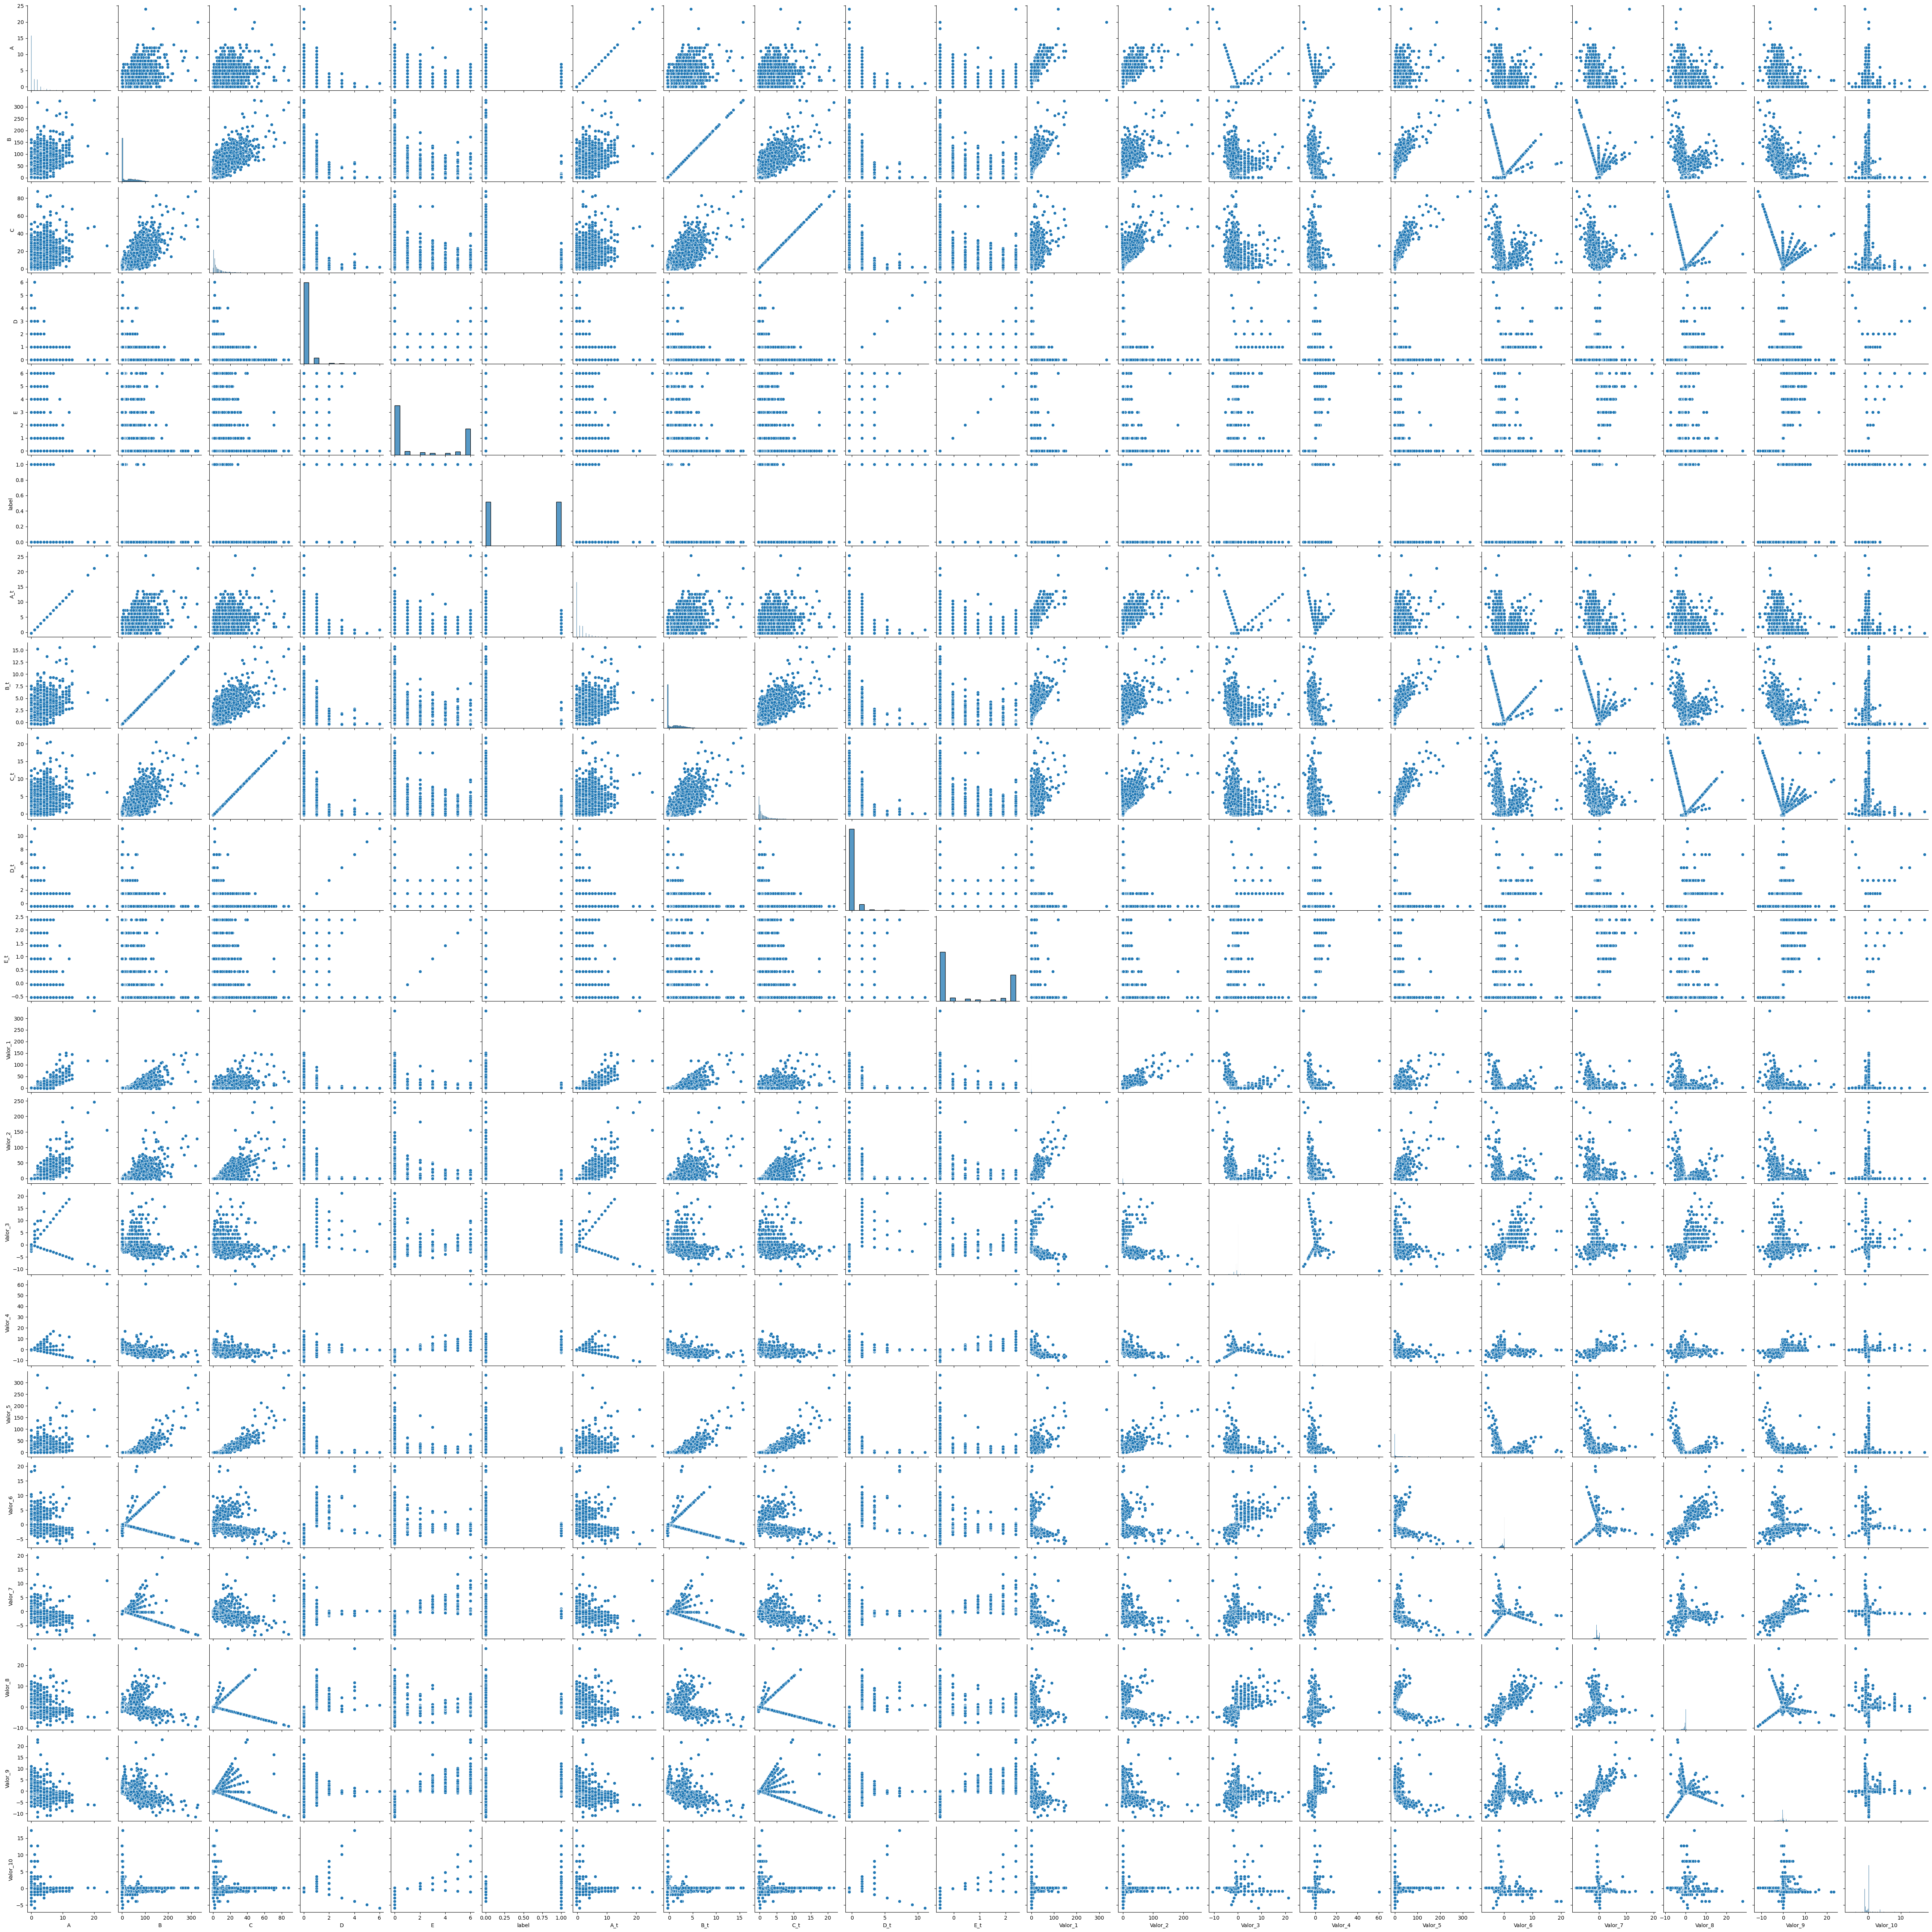

In [10]:
import seaborn as sns

# Crear una matriz de gráficos de dispersión (pairplot)
sns.pairplot(data)

In [11]:
# Eliminar columnas que empiecen por 'Valor_' y la columna 'comentario'
columnas_out = [col for col in data.columns if col.startswith('Valor_') or col == 'comentario']
data2 = data.drop(columns=columnas_out, errors='ignore')

# Mostrar las primeras filas del nuevo dataframe para verificar
print(data2.head())

   A   B   C  D  E  label       A_t       B_t        C_t       D_t       E_t
0  2  64  30  0  2    0.0  1.851102  2.759647   7.145831 -0.416577  0.440638
1  4  70  21  0  0    0.0  3.990202  3.054765   4.877255 -0.416577 -0.531099
2  4  88  50  0  0    0.0  3.990202  3.940120  12.187108 -0.416577 -0.531099
3  3  38  21  0  0    0.0  2.920652  1.480801   4.877255 -0.416577 -0.531099
4  0  59  17  0  0    0.0 -0.287998  2.513715   3.869000 -0.416577 -0.531099


In [12]:
# Separar las características y las etiquetas
features = data2.drop(columns=['label'])
labels   = data2['label']

In [13]:
# Estandarizar las columnas, excepto 'label'
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

features_std = scaler.fit_transform(features)

data_std = pd.DataFrame(features_std, columns=features.columns, index=features.index)
data_std['label'] = labels

print(data_std.head())

          A         B         C         D         E       A_t       B_t  \
0  0.598584  1.114413  3.324603 -0.258895 -0.073497  0.598584  1.114413   
1  1.746837  1.290828  2.094554 -0.258895 -0.806272  1.746837  1.290828   
2  1.746837  1.820075  6.058045 -0.258895 -0.806272  1.746837  1.820075   
3  1.172711  0.349946  2.094554 -0.258895 -0.806272  1.172711  0.349946   
4 -0.549669  0.967400  1.547866 -0.258895 -0.806272 -0.549669  0.967400   

        C_t       D_t       E_t  label  
0  3.324603 -0.258895 -0.073497    0.0  
1  2.094554 -0.258895 -0.806272    0.0  
2  6.058045 -0.258895 -0.806272    0.0  
3  2.094554 -0.258895 -0.806272    0.0  
4  1.547866 -0.258895 -0.806272    0.0  


### PCA

In [15]:
# Aplicar PCA
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Reducimos a 2 componentes principales
pca = PCA(n_components=2)
pca_result = pca.fit_transform(data_std.drop(columns=['label']))

# Crear un DataFrame con los resultados de PCA
data_pca = pd.DataFrame(pca_result, columns=['PC1', 'PC2'], index=data_std.index)
data_pca['label'] = data_std['label']

Varianza explicada por cada componente: [0.51835602 0.20028309]


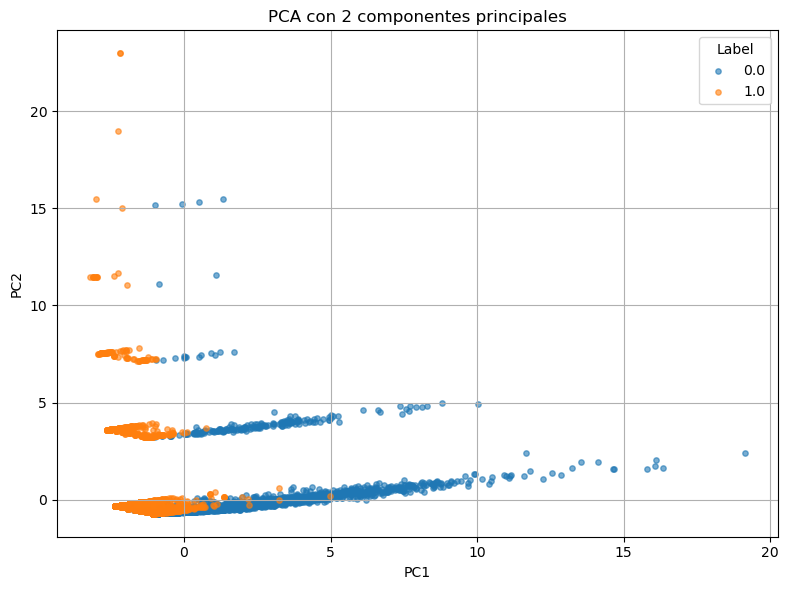

In [16]:
# Visualizar los resultados de PCA
plt.figure(figsize=(8, 6))

for label in data_pca['label'].unique():
    subset = data_pca[data_pca['label'] == label]
    plt.scatter(subset['PC1'], subset['PC2'], label=label, alpha=0.6, s=15)

print("Varianza explicada por cada componente:", pca.explained_variance_ratio_)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA con 2 componentes principales')
plt.legend(title='Label')
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
data_pca.head()

,PC1,PC2,label
0,3.863271,0.257069,0.0
1,4.253772,0.127813,0.0
2,7.663432,0.736383,0.0
3,3.115034,0.001730,0.0
4,2.094273,-0.313390,0.0


Accuracy: 0.9730

              precision    recall  f1-score   support

         0.0       0.98      0.97      0.97      1000
         1.0       0.97      0.98      0.97      1000

    accuracy                           0.97      2000
   macro avg       0.97      0.97      0.97      2000
weighted avg       0.97      0.97      0.97      2000

Matriz de confusión:


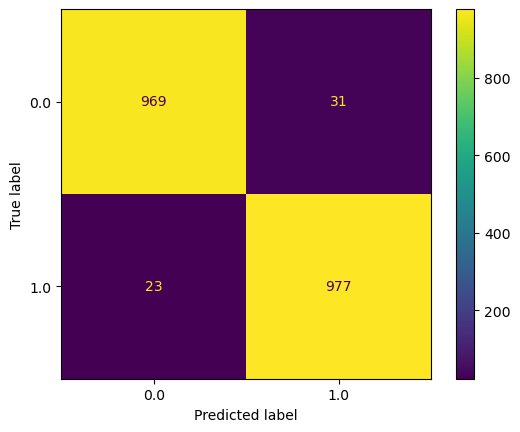

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#X = data_std.drop(columns=['label'])
#y = data_std['label']

X = data_pca.drop(columns=['label'])
y = data_pca['label']

# Dividir los datos en conjunto de entrenamiento y prueba
# 80% train 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Entrenar un modelo de clasificación (por ejemplo, RandomForest)
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest.fit(X_train, y_train)

# Predecir y evaluar el modelo
y_pred = random_forest.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}\n")

print(classification_report(y_test, y_pred))

print("Matriz de confusión:")
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=random_forest.classes_)
disp.plot()

**PCA** es una técnica estadística de reducción de la dimensionalidad que transforma un conjunto de datos multidimensional en uno de menor dimensión, capturando la mayor cantidad posible de varianza en los componentes principales. Su objetivo es simplificar los datos sin perder información relevante, facilitando la visualización y el análisis de los datos.

##### Varianza explicada
- La primera componente de PCA ("PC1") captura el 51.84% de la varianza total.
- La segunda componente ("PC2") explica el 20.03%.
- En conjunto, las dos primeras componentes concentran el 71.87% de la información inicial, lo que indica que gran parte de la estructura de los datos puede representarse adecuadamente en un espacio bidimensional.

##### Distribución de las clases
- En el diagrama de dispersión PC1 vs. PC2, las dos etiquetas aparecen en dos agrupamientos bastante diferenciados a lo largo de PC1, con un solapamiento mínimo.
- Esta separación indica que la mayor parte de la información discriminativa entre las dos clases se concentra en la dirección de PC1.

##### Rendimiento de clasificación con Random Forest
- Al entrenar un RandomForest (100 árboles) sobre las coordenadas (PC1, PC2), se alcanza un accuracy de **97.30%** en el conjunto de prueba.
- Para la **etiqueta "0"**:
  - Precisión = 97.68%
  - Recall = 96.90%
  - F1-score = 97.29%
- Para la **etiqueta "1"**:
  - Precisión = 96.92%
  - Recall = 97.70 %
  - F1-score = 97.31%

Estos resultados, aún siendo excelentes, no superan el nivel de accuracy obtenido por el mismo modelo de Random Forest entrenado a partir del conjunto completo de datos estandarizados, que alcanza un 98.05%.

##### Conclusiones
La reducción a dos componentes mediante PCA retiene algo más del 71% de la varianza y genera un espacio bidimensional en el que un clasificador simple logra una separación excelente de las dos clases.

Reducir a dos dimensiones mejora la interpretabilidad y acelera el entrenamiento, pero a coste de un ligero descenso en el accuracy. Este descenso en accuracy de PCA frente al conjunto completo de datos se debe fundamentalmente a que las dos primeras componentes de PCA no recogen por completo toda la varianza (ni la información discriminativa) presente en el conjunto original de datos. Para maximizar la precisión, conviene mantener más componentes o combinar PCA con un método supervisado como, por ejemplo, LDA.

### t-SNE

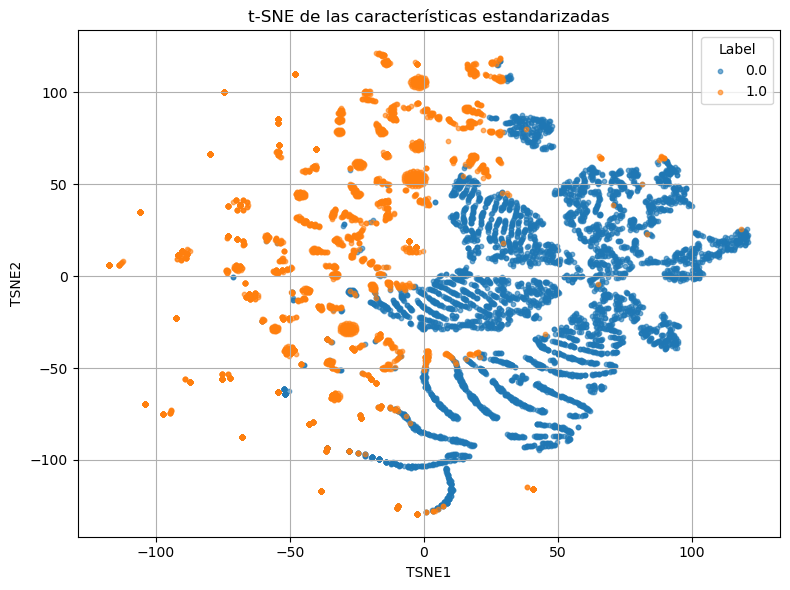

In [22]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Aplicar t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
tsne_results = tsne.fit_transform(data_std.drop(columns=['label']))

# Crear un DataFrame con los resultados de t-SNE
data_tsne = pd.DataFrame(tsne_results, columns=['TSNE1', 'TSNE2'])
data_tsne['label'] = data_std['label'].values

# Visualizar los resultados de t-SNE
plt.figure(figsize=(8, 6))

for label in data_tsne['label'].unique():
    subset = data_tsne[data_tsne['label'] == label]
    plt.scatter(subset['TSNE1'], subset['TSNE2'], label=label, alpha=0.6, s=10)

plt.title('t-SNE de las características estandarizadas')
plt.xlabel('TSNE1')
plt.ylabel('TSNE2')
plt.legend(title='Label')
plt.grid(True)
plt.tight_layout()
plt.show()

**t-SNE** (o incrustación de vecinos estocásticos distribuidos en t) es un método que proyecta datos multidimensionales en un espacio de menor dimensionalidad, preservando principalmente las relaciones locales de proximidad entre puntos.

##### Estructura local preservada
- El conjunto de coordenadas bidimensionales que produce t-SNE forma dos clusters compactos correspondientes a cada etiqueta, con fronteras más nítidas que los clusters obtenidos con PCA.
- Las instancias de la misma clase quedan muy próximas, maximizando la cohesión de los clusters y asegurando que los elementos de una misma categoría queden bien agrupados en el plano 2D.

##### Separación no lineal
- A diferencia de PCA, t-SNE revela patrones no lineales: las dos nubes de puntos no siguen un eje único, sino que adoptan formas que distinguen mejor subgrupos internos.

##### Conclusiones
El método t-SNE ofrece una visualización más clara de las relaciones locales entre muestras, mostrando clusters mejor aislados y capturando estructuras no lineales que PCA no evidencia.

### Utilizar t-SNE para clasificar

In [26]:
data_tsne.head()

,TSNE1,TSNE2,label
0,57.329483,5.015404,0.0
1,78.027466,30.188646,0.0
2,63.770958,19.486536,0.0
3,101.380363,24.102718,0.0
4,68.721054,-17.338264,0.0


Accuracy: 0.9810

              precision    recall  f1-score   support

         0.0       0.99      0.98      0.98      1000
         1.0       0.98      0.99      0.98      1000

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000

Matriz de confusión:


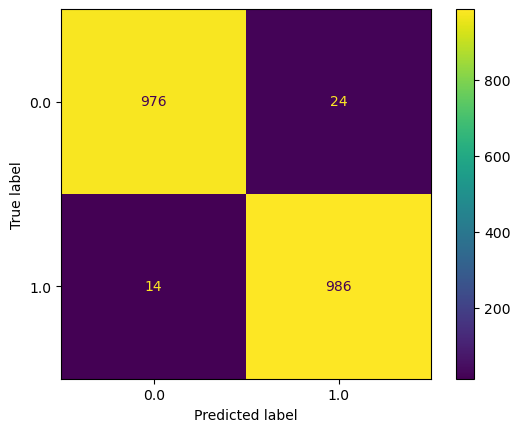

In [27]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

#X_tsne = data_std.drop(columns=['label'])
#y_tsne = data_std['label']

X_tsne = data_tsne.drop(columns=['label'])
y_tsne = data_tsne['label']

# Dividir los datos en conjunto de entrenamiento y prueba
# 80% train 20% test
X_train_tsne, X_test_tsne, y_train_tsne, y_test_tsne = train_test_split(
    X_tsne, y_tsne,
    test_size=0.2,
    random_state=42,
    stratify=y_tsne
)

# Entrenar un modelo de clasificación (por ejemplo, RandomForest)
random_forest_tsne = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_tsne.fit(X_train_tsne, y_train_tsne)

# Predecir y evaluar el modelo
y_pred_tsne = random_forest_tsne.predict(X_test_tsne)

acc_tsne = accuracy_score(y_test_tsne, y_pred_tsne)
print(f"Accuracy: {acc_tsne:.4f}\n")

print(classification_report(y_test_tsne, y_pred_tsne))

print("Matriz de confusión:")
cm_tsne = confusion_matrix(y_test_tsne, y_pred_tsne)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_tsne, display_labels=random_forest_tsne.classes_)
disp.plot()

Aunque es factible ajustar un clasificador sobre las coordenadas producidas por t-SNE, no es aconsejable por varios motivos:

- t-SNE es un método orientado a mejorar la visualización, que preserva relaciones locales en el plano 2D/3D, pero no para proporcionar características consistentes y generalizables en tareas de predicción.

- Sensibilidad a hiperparámetros. Usar las coordenadas de t-SNE como características para un clasificador implica que, ante cualquier cambio mínimo en sus hiperparámetros (perplexity, learning rate) o de la inicialización aleatoria, el clasificador se entrene sobre un espacio distinto, con lo cual sus resultados no serían reproducibles ni estables.

- Coste computacional para el cálculo de t-SNE, ya que este método no genera una función explícita para proyectar nuevas muestras, y cada nuevo dato exige recalcular todo el embedding.

Por tanto, para pipelines de clasificación en producción es más conveniente usar técnicas con función de transformación fija como, por ejemplo, PCA o LDA.

### LDA

In [31]:
import nltk
from nltk.corpus import stopwords
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

# Descargar las palabras vacías en español
nltk.download('stopwords')
stop_es = stopwords.words('spanish')

# Preprocesar la columna 'comentario'
vectorizer = CountVectorizer(
    stop_words=stop_es,
    token_pattern=r'(?u)\b[a-záéíóúñü]{3,}\b', # tokens de 3 letras o más
    ngram_range=(1,2),                         # unigramas y bigramas
    min_df=10,                                 # descarta términos con menos de 10 documentos
    max_df=0.3                                 # descarta términos presentes en más del 30% de documentos
)
X = vectorizer.fit_transform(data['comentario'].fillna(''))

# Aplicar LDA
lda = LatentDirichletAllocation(
    n_components=5,
    max_iter=10,
    random_state=42
)

lda.fit(X)

# Mostrar los temas
words = vectorizer.get_feature_names_out()
for idx, tema in enumerate(lda.components_):
    top_idx = tema.argsort()[-10:][::-1]
    top_words = [words[i] for i in top_idx]
    print(f"Tema {idx}: {', '.join(top_words)}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ivan.molera/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Tema 0: primero, nuevo, solo, vez, humano, sistema, dos, cientifico, forma, ver
Tema 1: gobierno, obra, españa, nuevo, politico, museo, andaluz, primero, parte, dos
Tema 2: dia, persona, dos, hora, abc, hoy, caso, primero, tras, segun
Tema 3: medio, estudio, agua, animal, seguir, segun, cambio, zona, climatico, explicar
Tema 4: decir, primero, libro, vez, vida, mismo, solo, mundo, ver, mujer


- Preprocesamiento: Este paso convierte el texto en una matriz de términos.
- Aplicación de LDA: Ejecuta el algoritmo LDA para encontrar los temas.
- Visualización de Temas: Imprime los temas encontrados con las palabras más representativas.

### LDA en función del label

In [34]:
import nltk
from nltk.corpus import stopwords
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import ConfusionMatrixDisplay

In [35]:
# Descargar las palabras vacías en español
nltk.download('stopwords')
stop_es = stopwords.words('spanish')


# Definir función para aplicar LDA y obtener temas
def apply_lda(texts):
    vectorizer = CountVectorizer(
        stop_words=stop_es,
        token_pattern=r'(?u)\b[a-záéíóúñü]{3,}\b', # tokens de 3 letras o más
        ngram_range=(1,2),                         # unigramas y bigramas
        min_df=10,                                 # descarta términos con menos de 10 documentos
        max_df=0.3                                 # descarta términos presentes en más del 30% de documentos
    )
    
    X = vectorizer.fit_transform(texts)

    # Aplicar LDA
    lda = LatentDirichletAllocation(
        n_components=5,
        max_iter=10,
        random_state=42
    )

    lda.fit(X)

    words = vectorizer.get_feature_names_out()
    temas = []
    for idx, tema in enumerate(lda.components_):
        top_idx = tema.argsort()[-10:][::-1]
        top_words = [words[i] for i in top_idx]
        temas.append({
            'topic': idx,
            'top_words': ', '.join(top_words)
        })

    return temas, lda, vectorizer


results = {}

# Aplicar LDA por cada etiqueta de label y guardar en archivos CSV
for label, group in data.groupby('label'):
    texts = group['comentario'].fillna('').tolist()

    temas, lda_model, vectorizer = apply_lda(texts)

    # Crear un DataFrame para los temas
    data_temas = pd.DataFrame(temas)

    # Guardar el DataFrame en un archivo CSV
    data_temas.to_csv(f'temas_labels_{label}.csv', index=False)

    results[label] = {
        'lda': lda_model,
        'vectorizer': vectorizer
    }

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/ivan.molera/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Matriz de confusión:


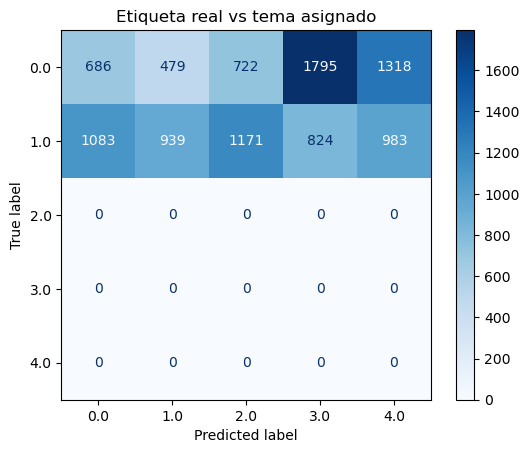

In [36]:
# Generar bolsas de palabras para cada tema
for label, info in results.items():
    lda_model  = info['lda']
    vectorizer = info['vectorizer']
    words      = vectorizer.get_feature_names_out()

    data_bow = pd.DataFrame(
        lda_model.components_.T,
        index=words,
        columns=[f'tema_{i}' for i in range(lda_model.n_components)]
    )
    data_bow.to_csv(f'bow_label_{label}.csv')

# Asignar temas a comentarios
assigned = []

# Asignar temas a comentarios y comparar con etiquetas reales
for label, group in data.groupby('label'):
    lda_model  = results[label]['lda']
    vect       = results[label]['vectorizer']
    texts      = group['comentario'].fillna('').tolist()
    X          = vect.transform(texts)
    topic_dist = lda_model.transform(X)
    topic_pred = topic_dist.argmax(axis=1)

    assigned.append(pd.DataFrame({
        'label_real': label,
        'comentario': texts,
        'tema_asignado': topic_pred
    }))

data_assigned = pd.concat(assigned, ignore_index=True)
data_assigned.to_csv('temas_asignados.csv', index=False)

# Comparar temas asignados con etiquetas reales
cm = confusion_matrix(data_assigned['label_real'], data_assigned['tema_asignado'])

disp = ConfusionMatrixDisplay.from_predictions(
    data_assigned['label_real'],
    data_assigned['tema_asignado'],
    normalize=None,
    cmap=plt.cm.Blues
)

print("Matriz de confusión:")
disp.ax_.set_title("Etiqueta real vs tema asignado")
plt.show()